In [333]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np
from astropy.cosmology import LambdaCDM

import time
import emcee
from multiprocessing import Pool

In [237]:
file = 'data/DES-Dovekie_HD.csv'

with open(file) as f:
    for i, line in enumerate(f):
        if line.startswith('VARNAMES:'):
            header_line = line
            header_idx = i
            break

cols = header_line.replace("VARNAMES:", "").split()

df = pd.read_csv(file, sep='\s+', skiprows=header_idx + 1, header=None).iloc[:, 1:]
df.columns = cols

low_z = df[df['IDSURVEY'] != 10]
high_z = df[df['IDSURVEY'] == 10]
high_z

,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS
187,1371046,10,0.07334,0.07411,37.60807,0.1792,0.0307,0.39882,1.00000
188,1318737,10,0.07374,0.07451,37.36177,0.1858,0.0305,0.06818,1.00000
199,1864053,10,0.09333,0.09422,38.14556,0.0994,0.0243,0.06934,1.00000
200,1344303,10,0.09394,0.09475,38.19696,0.2395,0.0242,0.13223,0.99969
201,1317612,10,0.10442,0.10525,38.35683,0.1256,0.0218,0.02734,0.99996
...,...,...,...,...,...,...,...,...,...
1815,1263785,10,1.06420,1.06498,44.23028,0.1451,0.0028,0.03884,0.99765
1816,1842087,10,1.08349,1.08430,44.52159,0.1518,0.0027,0.13563,0.99789
1817,1339609,10,1.12132,1.12212,44.20175,0.1075,0.0026,0.06526,0.98858
1818,1446080,10,1.13057,1.13140,44.52710,0.1585,0.0026,0.11217,0.99945


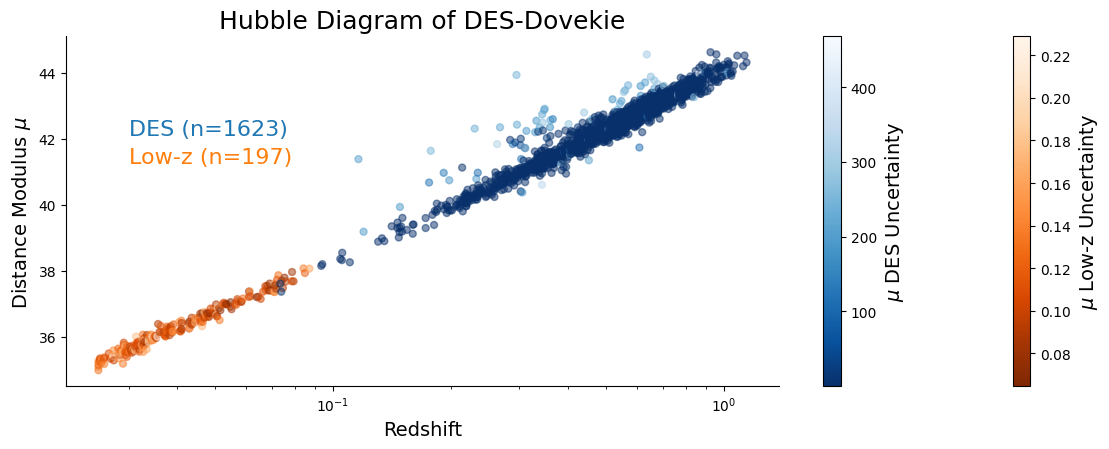

In [238]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

remove high MU uncertainty points

In [239]:
low_z = low_z[low_z['MUERR'] < 0.4]
high_z = high_z[high_z['MUERR'] < 0.4]

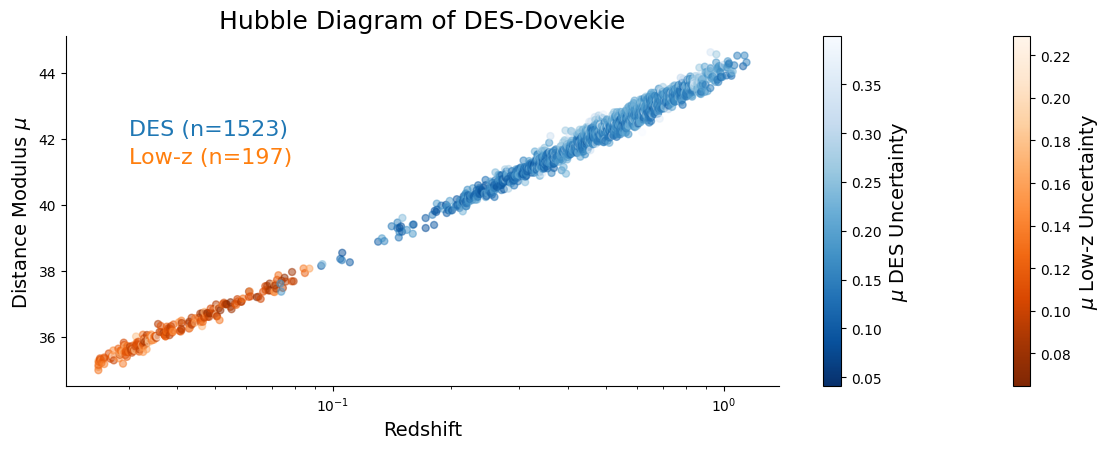

In [240]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# MCMC

In [241]:
def precompute_grid(zs, num_samples=5000):
    """Precompute the integration grid for fast distance calculations.
    
    Parameters
    ----------
        zs : array_like
            Redshift values where the distances will be evaluated. 
        num_samples : int, optional
            Number of bins used in the Riemann sum integration, default is 5000.
            
    Returns
    -------
        z_edges : np.ndarray
            Edges of redshift bins used for integration.
        dz : np.ndarray
            Width of each redshift bin.            
    Notes
    -----
    - This function should be run ONCE before the MCMC loop
    """
    zs = np.asarray(zs)
    
    z_edges = np.linspace(0, zs.max(), num_samples) # create evenly spaced bins in redshift space
    dz = np.diff(z_edges) # bin widths
    
    return z_edges, dz

def calc_dist(params, z_edges, dz, zs):
    """Compute the distance in Mpc given parameters and redshift.
    
    Parameters
    ----------
        params : list[float]
            Cosmological parameters [H_0, Om_m, Om_k, Om_l].
        z_edges : np.ndarray
            Edges of integration grid.
        dz : np.ndarray
            Bin widths.
        zs : array_like
            Redshift values.
            
    Returns
    -------
    distances : np.ndarray
        Distances (in Mpc) for each redshift.
    
    """
    H_0, Om_m, Om_l = params
    zs = np.asarray(zs)
    
    Om_k = 1 - Om_m - Om_l # compute Om_k from Om_m and Om_l relationship

    # 1.0 / H(z) evaluted at the edges
    Hz_inv = 1.0 /  (H_0 * np.sqrt(Om_m * (1.0 + z_edges)**3 +
                                   Om_k * (1.0 + z_edges)**2 +
                                   Om_l))

    cum_int = np.cumsum(0.5 * (Hz_inv[1:] + Hz_inv[:-1]) * dz) # trapezoidal cumulative integral
    cum_int = np.insert(cum_int, 0, 0.0)
    
    vals = np.interp(zs, z_edges, cum_int)

    return (1.0 + zs) * 3e5 * vals

In [ ]:
def ln_prior(params):
    H_0, Om_m, Om_l = params
    if H_0 < 0:
        return -np.inf
    elif Om_m < 0 or Om_m > 1:
        return -np.inf
    elif Om_l < 0 or Om_l > 1:
        return -np.inf
    else:
        return 0
    
def ln_likelihood(params, data_df):
    H_0, Om_m, Om_l = params
        
    cosmo = LambdaCDM(H0=H_0, Om0=Om_m, Ode0=Om_l) # use astropy for more acurate computing of the comoving distance
    mu_model = cosmo.distmod(data_df['zHD']).value
    
    residuals = data_df['MU'] - mu_model
        
    chi2 = (residuals / data_df['MUERR']) ** 2
    return -0.5 * np.sum(chi2)

def ln_pdf(params):
    p = ln_prior(params)
    if p == -np.inf:
        return -np.inf
    return p + ln_likelihood(params, high_z)

In [ ]:
n_dim, n_walkers = 3, 16
n_iterations = 5000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0.7], cov=np.diag([1, 1e-12, 1e-12]), size=n_walkers)

print([ln_prior(x) for x in p0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [244]:
with Pool() as pool:
    start = time.time()
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, ln_pdf, pool=pool)
    sampler.run_mcmc(p0, n_iterations, progress=True)
    dur = time.time() - start
    print(f'MCMC took {dur:.3f} seconds')

100%|██████████| 5000/5000 [01:30<00:00, 55.20it/s]


MCMC took 90.604 seconds


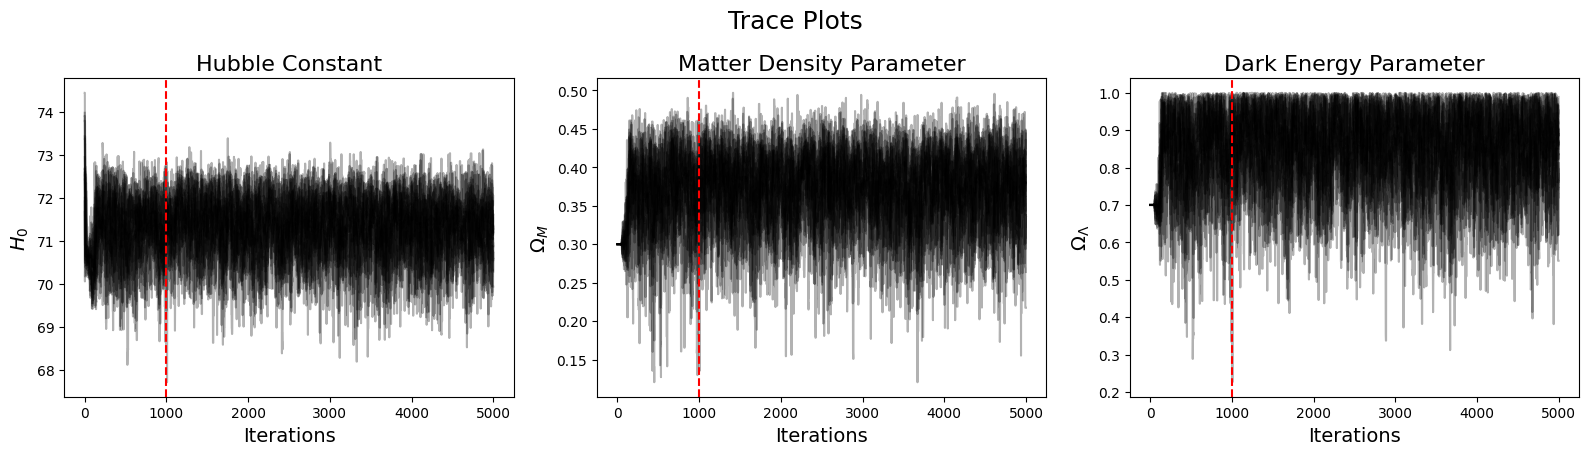

In [271]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Dark Energy Parameter']
y_labels = [r'$H_0$', r'$\Omega_M$', r'$\Omega_\Lambda$']
for i in range(0, 3):
    axs[i].plot(sampler.get_chain()[:,:,i], 'k', alpha=0.3)
    axs[i].set_xlabel('Iterations', size=14)
    axs[i].set_title(titles[i], size=16)
    axs[i].set_ylabel(y_labels[i], size=14)
    axs[i].axvline(x=1000, color='red', linestyle='dashed')

fig.suptitle('Trace Plots', size=18)
plt.tight_layout()
plt.show()

In [256]:
burned = pd.DataFrame(sampler.get_chain(discard=1000, flat=True), columns=['H_0', 'Om_m', 'Om_l'])
burned['Om_k'] = 1.0 - burned['Om_m'] - burned['Om_l']
burned = burned.sort_values(by='Om_m')

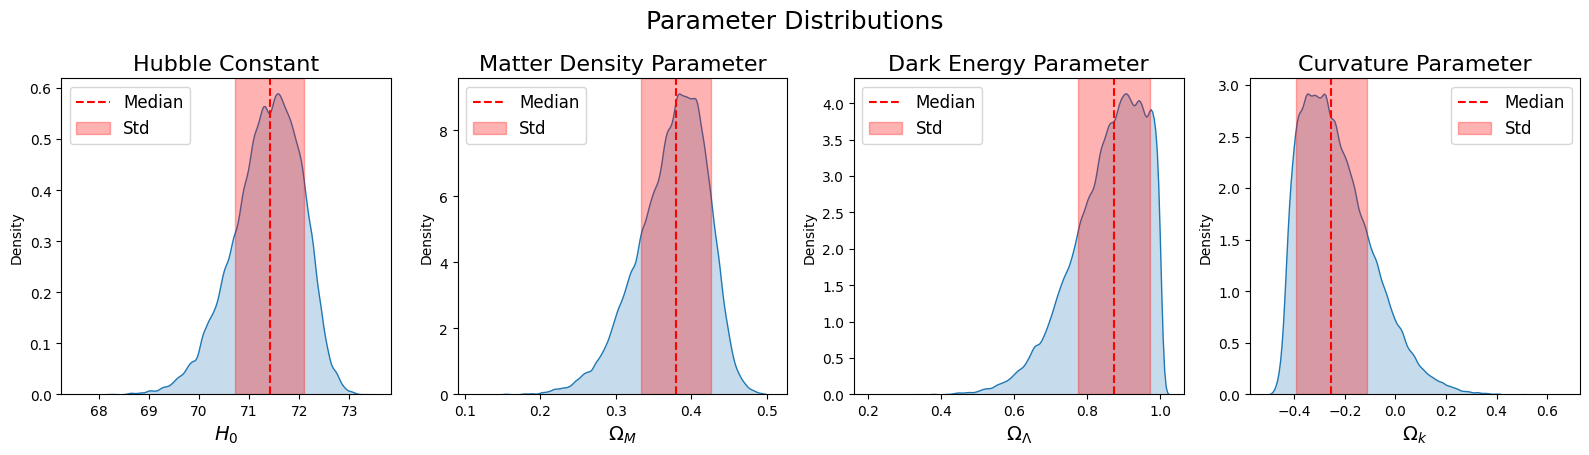

In [273]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Dark Energy Parameter', 'Curvature Parameter']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\Omega_\Lambda$', r'$\Omega_k$']
for i in range(0, 4):
    sns.kdeplot(burned.iloc[:,i], fill=True, ax=axs[i], bw_adjust=0.7)
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(burned.iloc[:,i])
    std = np.std(burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [274]:
print(f'H_0  = {np.median(burned.iloc[:,0]):.2f} ± {np.std(burned.iloc[:,0]):.2f} km / s / Mpc')
print(f'Om_m = {np.median(burned.iloc[:,1]):.2f} ± {np.std(burned.iloc[:,1]):.2f}')
print(f'Om_l = {np.median(burned.iloc[:,2]):.2f} ± {np.std(burned.iloc[:,2]):.2f}')
print(f'Om_k = {np.median(burned.iloc[:,3]):.2f} ± {np.std(burned.iloc[:,3]):.2f}')

H_0  = 71.41 ± 0.68 km / s / Mpc
Om_m = 0.38 ± 0.05
Om_l = 0.87 ± 0.10
Om_k = -0.25 ± 0.14


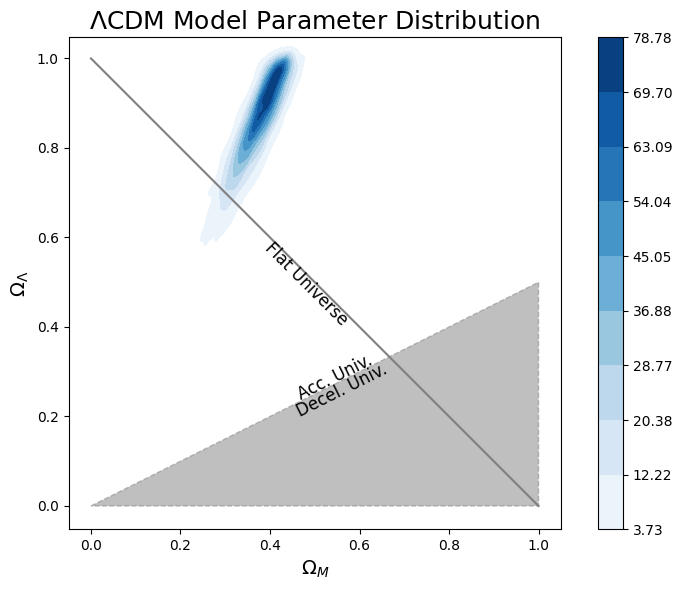

In [398]:
fig, ax = plt.subplots(figsize=(8,6))
ax.set_aspect('equal')

sns.kdeplot(x=burned['Om_m'], y=burned['Om_l'], cmap='Blues', fill=True, cbar=True)

X = np.linspace(0, 1, 100)
plt.plot(X, 1 - X, color='gray')
plt.fill_between(X, 0.5*X, color='gray', alpha=0.5, linestyle='dashed')

rotn = np.degrees(np.arctan2(1, 2))
plt.annotate('Acc. Univ.', xy=(0.545, 0.2875), ha='center', va='center', rotation=rotn, fontsize=12)
plt.annotate('Decel. Univ.', xy=(0.56, 0.2575), ha='center', va='center', rotation=rotn, fontsize=12)

rotn = np.degrees(np.arctan2(X[0]-X[1], X[1]-X[0]))
plt.annotate('Flat Universe', xy=(0.48, 0.495), ha='center', va='center', rotation=rotn, fontsize=12)

plt.xlabel('$\Omega_M$', size=14)
plt.ylabel('$\Omega_\Lambda$', size=14)
# plt.xlim(0.11, 0.65)
# plt.ylim(0.21, 0.79)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(0.15))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.15))
plt.title('$\Lambda$CDM Model Parameter Distribution', size=18)
plt.tight_layout()
plt.show()